# This Script is for analysis on Chirps precip data

In [1]:
import os
import requests
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from scipy.stats import spearmanr # Using for Spearman Rank Correlation
import xarray as xr

In [5]:
# Arizona (Willcox Basin)
et_gw_merged_all_sites = "/capstone/aridgw/data//et_precip_gw_merged_all_sites.csv"
et_gw_merged_all_sites = pd.read_csv(et_gw_merged_all_sites)

In [3]:
import rasterio
import numpy as np
import glob

data_dir = "/capstone/aridgw/data/chirps_daily_data/"

# Filter files for 2000-2026 only
files = sorted(glob.glob(data_dir + "*.tif"))
files = [f for f in files if any(str(year) in f for year in range(2000, 2027))]
print(len(files), "files found")

# Read first file to get metadata
with rasterio.open(files[0]) as src:
    meta = src.meta.copy()
    shape = src.shape

# Initialize sum array
precip_sum = np.zeros(shape, dtype=np.float64)

# Read and sum all files
for i, f in enumerate(files):
    with rasterio.open(f) as src:
        precip_sum += src.read(1)
    if i % 100 == 0:
        print(f"Processed {i}/{len(files)}")

# Calculate mean
precip_mean = precip_sum / len(files)

# Write output
meta.update(dtype=rasterio.float32)
with rasterio.open("/capstone/aridgw/data/chirps_daily_precip_normal_2000_2026.tif", 'w', **meta) as dst:
    dst.write(precip_mean.astype(np.float32), 1)

9528 files found
Processed 0/9528
Processed 100/9528
Processed 200/9528
Processed 300/9528
Processed 400/9528
Processed 500/9528
Processed 600/9528
Processed 700/9528
Processed 800/9528
Processed 900/9528
Processed 1000/9528
Processed 1100/9528
Processed 1200/9528
Processed 1300/9528
Processed 1400/9528
Processed 1500/9528
Processed 1600/9528
Processed 1700/9528
Processed 1800/9528
Processed 1900/9528
Processed 2000/9528
Processed 2100/9528
Processed 2200/9528
Processed 2300/9528
Processed 2400/9528
Processed 2500/9528
Processed 2600/9528
Processed 2700/9528
Processed 2800/9528
Processed 2900/9528
Processed 3000/9528
Processed 3100/9528
Processed 3200/9528
Processed 3300/9528
Processed 3400/9528
Processed 3500/9528
Processed 3600/9528
Processed 3700/9528
Processed 3800/9528
Processed 3900/9528
Processed 4000/9528
Processed 4100/9528
Processed 4200/9528
Processed 4300/9528
Processed 4400/9528
Processed 4500/9528
Processed 4600/9528
Processed 4700/9528
Processed 4800/9528
Processed 4900/

In [6]:
import rasterio
import numpy as np

et_gw_merged_all_sites = et_gw_merged_all_sites.copy()

# CHIRPS uses -180 to 180, so no conversion needed (unless your data uses 0-360)
with rasterio.open("/capstone/aridgw/data/chirps_daily_precip_normal_2000_2026.tif") as src:
    coords = list(zip(
        et_gw_merged_all_sites["longitude"],
        et_gw_merged_all_sites["latitude"]
    ))
    values = [v[0] for v in src.sample(coords)]

et_gw_merged_all_sites["chirps_precip_normal"] = values

In [7]:
et_gw_merged_all_sites.head()

,MEDS_ID,MEDS_ANNUAL_MEDIAN_ROW,YEAR,WaterLevel_m,WaterLevelElev_masl,Title Location,Lat,Lon,tile_id,year,...,longitude,tile,mean_ET_mm_yr,buffer_radius_m,lon_360,gpcp_precip_normal,mean_precip_x,mean_precip_y,mean_precip,chirps_precip_normal
0,17,574,2003,67.60464,NaN,San Simon Valley,32.171194,-109.157837,h08v05,2003.0,...,-109.157837,h08v05,170.530762,1000.0,250.842163,0.0,328.70966,328.70966,328.70966,0.839337
1,17,575,2004,66.72072,NaN,San Simon Valley,32.171194,-109.157837,h08v05,2004.0,...,-109.157837,h08v05,230.538467,1000.0,250.842163,0.0,328.70966,328.70966,328.70966,0.839337
2,17,576,2005,71.56704,NaN,San Simon Valley,32.171194,-109.157837,h08v05,2005.0,...,-109.157837,h08v05,239.988449,1000.0,250.842163,0.0,328.70966,328.70966,328.70966,0.839337
3,17,577,2007,67.45224,NaN,San Simon Valley,32.171194,-109.157837,h08v05,2007.0,...,-109.157837,h08v05,276.661530,1000.0,250.842163,0.0,328.70966,328.70966,328.70966,0.839337
4,17,578,2008,82.02168,NaN,San Simon Valley,32.171194,-109.157837,h08v05,2008.0,...,-109.157837,h08v05,278.073059,1000.0,250.842163,0.0,328.70966,328.70966,328.70966,0.839337


In [8]:
# Calculate groundwater trend per site
df = et_gw_merged_all_sites.copy()

def calc_trend(group):
    # drop missing values
    g = group.dropna(subset=["YEAR", "WaterLevel_m"])
    if len(g) < 2:
        return np.nan
    
    # slope (m/year)
    slope = np.polyfit(g["YEAR"], g["WaterLevel_m"], 1)[0]
    return slope

gw_trends = df.groupby("location").apply(calc_trend).reset_index()
gw_trends.columns = ["location", "gw_trend_m_per_yr"]

# Compute ET : Precip ratio per site
climate = df.groupby("location").agg(
    mean_et=("mean_ET_mm_yr", "mean"),
    mean_precip=("chirps_precip_normal", "mean")
).reset_index()

# Multiply by 365 to get from mm/day to mm/year
climate["mean_precip"] = climate["mean_precip"] * 365

climate["et_precip_ratio"] = climate["mean_et"] / climate["mean_precip"]

# Merge them
site_summary = gw_trends.merge(climate, on="location")
site_summary

/tmp/ipykernel_904267/1997605303.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gw_trends = df.groupby("location").apply(calc_trend).reset_index()


,location,gw_trend_m_per_yr,mean_et,mean_precip,et_precip_ratio
0,Arizona (Willcox Basin),2.460569,257.231247,327.171600,0.786227
1,Butler Valley,1.909301,162.346309,168.758636,0.962003
2,Cuyama,0.427477,184.115132,275.070770,0.669337
3,Hualapai Valley Basin,1.564896,115.447110,265.514648,0.434805
4,McMulllen Valley,0.428793,91.588407,229.847305,0.398475
5,Nevada (Amargosa),0.281753,64.273913,117.857109,0.545355
6,San Simon Valley,2.353814,249.395189,306.358032,0.814064
7,Southern Willcox Basin,0.449900,173.828178,349.389465,0.497520


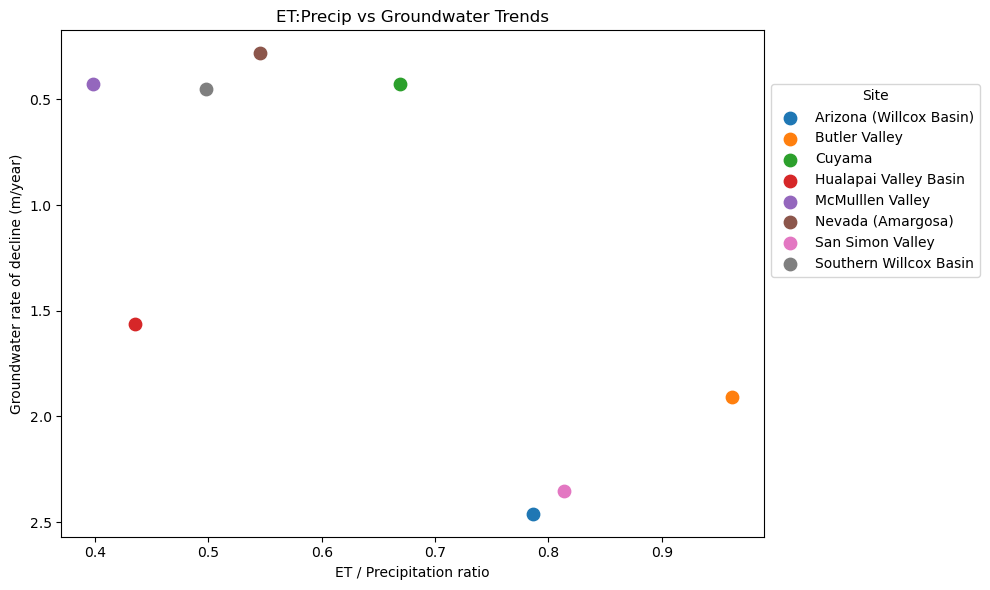

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Get unique sites and assign colors
sites = site_summary["location"].unique()
colors = plt.cm.tab10(range(len(sites)))

# Scatter points colored by site
for site, color in zip(sites, colors):
    subset = site_summary[site_summary["location"] == site]
    plt.scatter(subset["et_precip_ratio"],
                subset["gw_trend_m_per_yr"],
                label=site,
                color=color,
                s=80)

plt.xlabel("ET / Precipitation ratio")
plt.ylabel("Groundwater rate of decline (m/year)")
plt.title("ET:Precip vs Groundwater Trends")
plt.legend(title="Site", loc='lower left', bbox_to_anchor=(1, .5))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

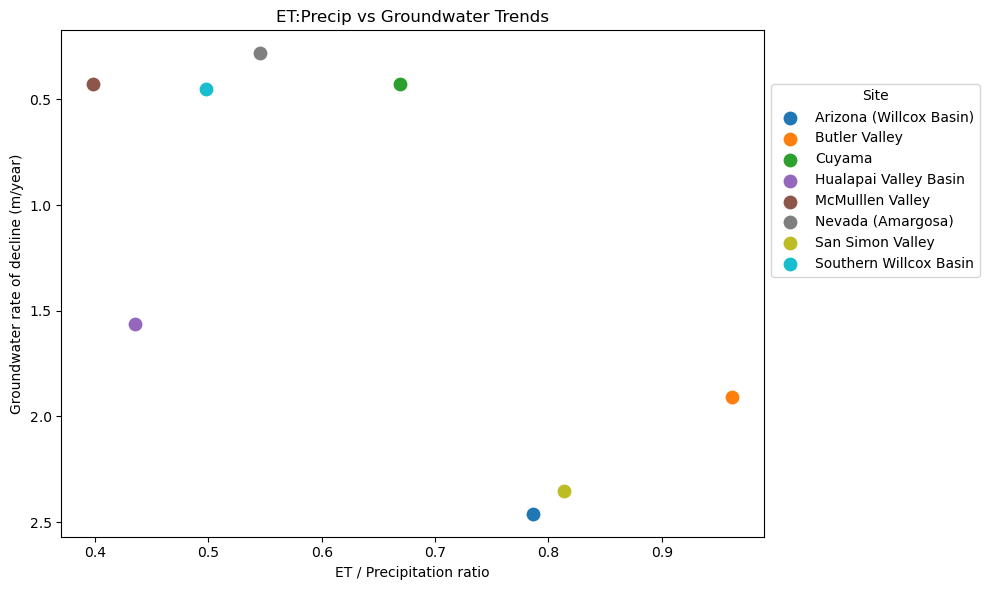

In [ ]:
import matplotlib.pyplot as plt

# Define consistent color mapping
site_colors = {
    "Arizona (Willcox Basin)": "#1f77b4",      # blue
    "Butler Valley": "#ff7f0e",                 # orange
    "Cuyama": "#2ca02c",                        # green
    "Hualapai Valley Basin": "#9467bd",         # purple
    "McMullen Valley": "#8c564b",               # brown
    "Nevada (Amargosa)": "#7f7f7f",             # gray
  